# Buổi 9: Học sâu

Cài đặt thư viện tensorflow
```bash
pip install tensorflow
```

## 1. Khai báo thư viện 

In [ ]:
%pip install tensorflow
import numpy as np
from tensorflow import keras    # thư viện keras cho deep learning
import matplotlib.pyplot as plt # thư viện vẽ đồ thị
import time

^C


ModuleNotFoundError: No module named 'tensorflow'

## 2. Chuẩn bị dữ liệu

In [ ]:
# tải dataset mnist từ thư viện dataset chuẩn trong keras
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

## 3. Hiển thị dữ liệu

In [ ]:
# Thông tin tập train
print(f'Train: n={len(x_train)}') 
print(f'+ x_train: {x_train.shape}, range = [{np.min(x_train)}, {np.max(x_train)}]') # shape + miền trị
print(f'+ y_train: {y_train.shape}, values= {np.unique(y_train)}') # shape + các giá trị output

# Thông tin tập test
print(f'Train: n={len(x_test)}') 
print(f'+ x_train: {x_test.shape}, range = [{np.min(x_test)}, {np.max(x_test)}]') # shape + miền trị
print(f'+ y_train: {y_test.shape}, values= {np.unique(y_test)}') # shape + các giá trị output

Train: n=60000
+ x_train: (60000, 28, 28), range = [0, 255]
+ y_train: (60000,), values= [0 1 2 3 4 5 6 7 8 9]
Train: n=10000
+ x_train: (10000, 28, 28), range = [0, 255]
+ y_train: (10000,), values= [0 1 2 3 4 5 6 7 8 9]


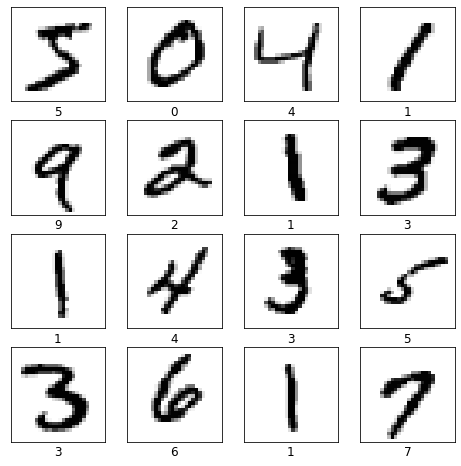

In [ ]:
# Hiển thị dữ liệu train
plt.figure(figsize=(8, 8))
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.xticks([]), plt.yticks([]), plt.grid(False)
    plt.imshow(x_train[i], cmap=plt.cm.binary)
    plt.xlabel(f'{y_train[i]}', fontsize = 12)
plt.show()

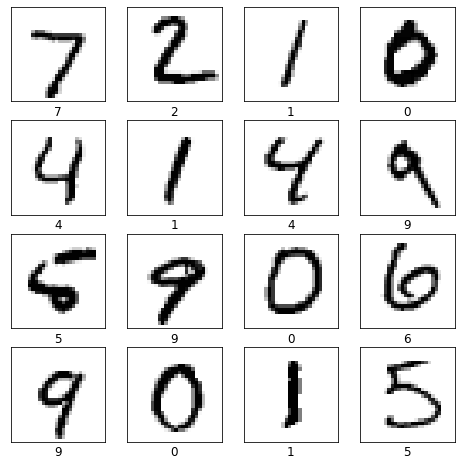

In [ ]:
# Hiển thị dữ liệu test
plt.figure(figsize=(8, 8))
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.xticks([]), plt.yticks([]), plt.grid(False)
    plt.imshow(x_test[i], cmap=plt.cm.binary)
    plt.xlabel(f'{y_test[i]}', fontsize = 12)
plt.show()

## 4. Tiền xử lý dữ liệu

In [ ]:
# Biến đổi ảnh về miền trị [0,1]
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255

In [ ]:
# Mở rộng shape tại chiều cuối cùng (n_images,28,28) --> (n_images, 28, 28, 1)
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

In [ ]:
print("x_train shape:", x_train.shape)
print(x_train.shape[0], "train samples")
print(x_test.shape[0], "test samples")

x_train shape: (60000, 28, 28, 1)
60000 train samples
10000 test samples


In [ ]:
# Chuyển đổi y_train, y_test sang dạng one-hot
num_classes = 10 # phân lớp 10 ký tự số (từ 0 đến 9)
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

In [ ]:
# dạng one-hot
y_train[0:10]

array([[0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.]], dtype=float32)

In [ ]:
# dùng np.argmax để tìm vị trí có giá trị xác suất lớn nhất (đưa về label)
np.argmax(y_train[0:10], axis = 1)

array([5, 0, 4, 1, 9, 2, 1, 3, 1, 4], dtype=int64)

## 5. Xây dựng Model

In [ ]:
# xóa các lưu trữ 
keras.backend.clear_session() 

# xây dựng model
input_shape = (28, 28, 1)

# input
input_ = keras.Input(shape=input_shape)

# các blocks convolution để lấy features
# block 1 (conv2d + activation + maxpool)
x = keras.layers.Conv2D(32, kernel_size=(3, 3), activation="relu")(input_)
x = keras.layers.MaxPooling2D(pool_size=(2, 2))(x)
# block 2 (conv2d + activation + maxpool)
x = keras.layers.Conv2D(64, kernel_size=(3, 3), activation="relu")(x)
x = keras.layers.MaxPooling2D(pool_size=(2, 2))(x)

# classification layers (gồm các dense layer, dropout)
x = keras.layers.Flatten()(x) # Đưa shape của x về dạng phẳng. Ví dụ: (28, 28, 1) --> (28x28x1, )
x = keras.layers.Dropout(0.5)(x) # Loại ngẫu nhiên 50% kết nối trong quá trình huấn luyện - tăng tính tổng quát hóa
output_ = keras.layers.Dense(num_classes, activation="softmax")(x) # kết xuất ra 10 classes dữ liệu dạng xác suất

model = keras.Model(inputs=input_, outputs=output_) # đưa vào model

model.summary() # hiển thị thông tin model

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 28, 28, 1)]       0         
                                                                 
 conv2d (Conv2D)             (None, 26, 26, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 13, 13, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 11, 11, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 5, 5, 64)         0         
 2D)                                                             
                                                                 
 flatten (Flatten)           (None, 1600)              0     

## 6. Huấn luyện Model

In [ ]:
# khai báo learning rate, loss function, và model metric
model.compile(loss='categorical_crossentropy', 
              optimizer=keras.optimizers.Adam(learning_rate=0.01), 
              metrics=["accuracy"])

batch_size = 128
epochs     = 15

starting_time = time.time()
model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_split=0.1)
print('> training time is %.4f minutes' % ((time.time() - starting_time)/60))

Epoch 1/15
422/422 [==============================] - 13s 29ms/step - loss: 0.1731 - accuracy: 0.9464 - val_loss: 0.0548 - val_accuracy: 0.9832
Epoch 2/15
422/422 [==============================] - 12s 29ms/step - loss: 0.0887 - accuracy: 0.9722 - val_loss: 0.0404 - val_accuracy: 0.9885
Epoch 3/15
422/422 [==============================] - 13s 30ms/step - loss: 0.0739 - accuracy: 0.9771 - val_loss: 0.0344 - val_accuracy: 0.9902
Epoch 4/15
422/422 [==============================] - 13s 30ms/step - loss: 0.0715 - accuracy: 0.9784 - val_loss: 0.0352 - val_accuracy: 0.9902
Epoch 5/15
422/422 [==============================] - 12s 30ms/step - loss: 0.0646 - accuracy: 0.9798 - val_loss: 0.0442 - val_accuracy: 0.9883
Epoch 6/15
422/422 [==============================] - 13s 30ms/step - loss: 0.0627 - accuracy: 0.9809 - val_loss: 0.0344 - val_accuracy: 0.9890
Epoch 7/15
422/422 [==============================] - 13s 31ms/step - loss: 0.0600 - accuracy: 0.9815 - val_loss: 0.0357 - val_accuracy:

In [ ]:
# list all data in history
print(model.history.history.keys())

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


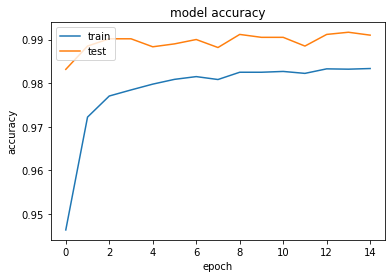

In [ ]:
# summarize history for accuracy
plt.plot(model.history.history['accuracy'])
plt.plot(model.history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

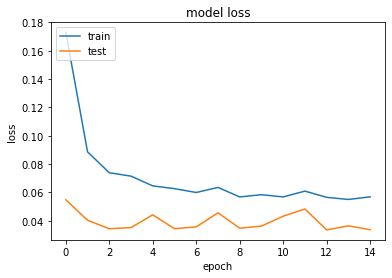

In [ ]:
# summarize history for loss
plt.plot(model.history.history['loss'])
plt.plot(model.history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

## 7. Lượng giá Model

In [ ]:
score = model.evaluate(x_test, y_test, verbose=0)
print("Test loss:", score[0])
print("Test accuracy:", score[1])

Test loss: 0.045329801738262177
Test accuracy: 0.986299991607666


In [ ]:
y_pred = model.predict(x_test)
y_pred_label = np.argmax(y_pred, axis = 1)
y_gt_label = np.argmax(y_test, axis = 1)

In [ ]:
# Các vị trí bị sai
false_pos = np.where(y_pred_label != y_gt_label)[0]
print(f'False Cases: {len(false_pos)} / {len(y_gt_label)}\n{false_pos}')

False Cases: 137 / 10000
[ 247  320  359  445  449  450  625  659  684  689  726  740  829  839
  882  938  947  965 1014 1032 1033 1039 1045 1112 1114 1178 1206 1226
 1232 1247 1260 1290 1326 1444 1520 1527 1681 1709 1718 1722 1790 1878
 1901 2035 2070 2093 2107 2118 2129 2130 2135 2195 2266 2280 2293 2329
 2406 2414 2462 2488 2597 2607 2654 2695 2720 2758 2896 2927 2939 2953
 3005 3060 3073 3225 3422 3520 3534 3726 3730 3767 3778 3806 3808 3838
 3850 4176 4205 4224 4256 4284 4380 4400 4500 4571 4740 4761 4807 4814
 4823 4837 4860 4956 5246 5997 6004 6173 6560 6561 6571 6576 6577 6597
 6625 6954 7434 7841 8043 8094 8102 8115 8160 8277 8316 8408 9009 9015
 9019 9530 9620 9634 9642 9664 9679 9692 9698 9729 9770]


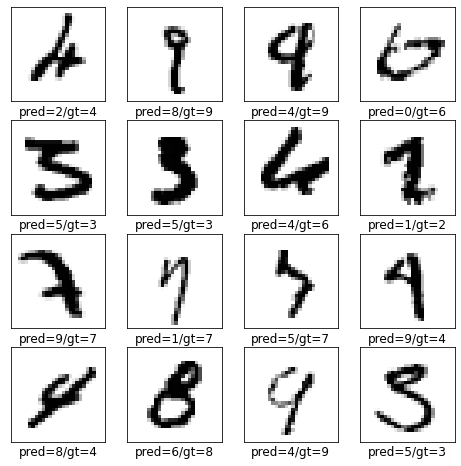

In [ ]:
# Hiển thị dữ liệu test
plt.figure(figsize=(8, 8))
for i in range(16):
    pos = false_pos[i]
    plt.subplot(4,4,i+1)
    plt.xticks([]), plt.yticks([]), plt.grid(False)
    plt.imshow(x_test[pos], cmap=plt.cm.binary)
    plt.xlabel(f'pred={y_pred_label[pos]}/gt={y_gt_label[pos]}', fontsize = 12)
plt.show()

# Kết thúc